# J-lens vs logit lens on GPT-2 XL — shared-activation dataset evaluation

Based on `notebooks/logit_lens/logit_lens_dataset.ipynb`, retaining every metric and diagnostic
across all six evaluation sets. For each prompt, **one forward pass** records the pre-`ln_f`
output of every block. The logit lens reads `unembed(h_l)`; the J-lens reads
`unembed(J_l @ h_l)`. Both use the same activations, tokenization, readout position, controls,
and exact final model logits. The final row is identical; compare inner layers separately.

Load a fitted lens for the selected model, or fit one on an independent mixed corpus below.
Results retain a `lens` column throughout; model accuracy is counted once per item.

**Protocol** (`data/evaluations/README.md`):

* **readout position** — one token per prompt: the last prompt token (the one right before `target`,
  the closing period, the tail of the typo); for poetry — the newline at the end of the first line;
* **rank** — 1-based rank of a word among all 50 257 tokens at that position, min over its single-token
  spellings (with/without leading space, case); for order-ops — min over the synonym set
  (numbers → digits and words, operations → symbols and words); multi-token words fall back to their first token;
* **pass@k** — mean over items of the fraction of `intermediates` whose min-over-layers rank ≤ k;
* **control** — the same ranks for the intermediates of *another* item of the same dataset.
  It is the chance level: a lens that surfaces any vaguely topical word scores here too.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# ноутбук открыт из клона репозитория (notebooks/<lens>/) — ищем его корень выше по дереву
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "gpt2" / "lens_eval.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

Cloning into '/content/jacobian-lens-gpt2'...
remote: Enumerating objects: 177, done.
remote: Counting objects: 100% (139/139), done.
remote: Compressing objects: 100% (96/96), done.
remote: Total 177 (delta 68), reused 99 (delta 41), pack-reused 38 (from 1)
Receiving objects: 100% (177/177), 3.84 MiB | 8.93 MiB/s, done.
Resolving deltas: 100% (70/70), done.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import jlens
from jlens.sharded_fitting import benchmark_dim_batches
from gpt2 import GPT2LensModel
from gpt2.lens_eval import (
    DATASETS,
    FIT_MIX,
    ROLE_NAMES,
    evaluate_paired,
    first_layer,
    fit_with_progress,
    identity_lens,
    layer_hit_rate,
    layer_mean,
    layer_median_rank,
    load_eval,
    load_fit_prompts,
    pass_at_k,
    plot_layer_curves,
    shown_layers,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = "openai-community/gpt2-xl"  # 1.5B parameters, 48 layers, d_model 1600
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_DTYPE = torch.float32  # Explicit: no reduced-precision fitting by default.

gpt = GPT2LensModel.from_pretrained(MODEL_ID, device=DEVICE, dtype=MODEL_DTYPE)
LENS_NAMES = ("logit lens", "J-lens")
LAYER_STRIDE = 4
assert gpt.n_layers >= 2, "The inner-layer comparison needs at least two layers."
gpt

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 6.43GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

GPT2LensModel(n_layers=48, d_model=1600)

In [4]:
evals = {dataset: load_eval(REPO_DIR, dataset) for dataset in DATASETS}

K = 10
KS = sorted({1, 5, 10, 100, K})
LAST = gpt.n_layers - 1
{dataset: len(samples) for dataset, samples in evals.items()}

{'multihop': 93,
 'multilingual': 107,
 'order-ops': 55,
 'poetry': 98,
 'association': 102,
 'typo': 96}

## Load or fit the J-lens

### Persistence and resume
In Colab, the next cell mounts Google Drive and stores the final lens, resumable checkpoint,
ordered corpus, and metadata under `MyDrive/jacobian-lens-runs`. Outside Colab it never mounts
Drive: it uses `~/jacobian-lens-runs` (change `LOCAL_ROOT` as needed). Setting
`USE_GOOGLE_DRIVE=False` explicitly opts into local storage; Colab local files are ephemeral.
A failed Drive mount stops rather than silently writing checkpoints to temporary storage.
Paths include the full model slug, actual dtype, sequence limit, run label, and a configuration
hash. Keep the entire run directory together, and do not run concurrent writers in it.

**A managed final `LENS_PATH` skips downloads, benchmarks, and fitting only after its
manifest and saved ordered-corpus fingerprint are verified.** Keep both sidecars.
For an older final lens without compatible sidecars, set
`EXISTING_LENS_PATH = Path("/absolute/path/to/previous/lens.pt")` in the configuration cell.
This is an explicit **unverified legacy opt-in**, with no refit: only width and layer
coverage are checked, not model identity or corpus provenance. Do not use a checkpoint.
The expanded configuration changes run hashes: prior outputs will not be discovered
automatically. Use that explicit legacy path rather than rewriting old manifests.

Otherwise the actual ordered corpus (`source`, `text`) is saved before any fit and reused
without downloading on resume. A sidecar checks configuration and corpus SHA-256; missing
metadata beside a checkpoint is rejected. This is a notebook safeguard, not a complete
checkpoint provenance guarantee: `fit()` itself only checks source/target layers and
`skip_first` when present, not model weights, dtype, sequence length, prompt order, or batch
size. Do not transplant checkpoints or edit their sidecars. Pin your model/corpus revisions
for reproducibility; change `RUN_LABEL` for a fresh corpus/run. Check the source counts:
the streaming loader can skip unavailable sources. Evaluation prompts are never fit data.

### One model, one single-worker fit, measured batch selection
`DIM_BATCH=None` automatically benchmarks candidates on the longest and median-length valid
prompts in the **saved actual corpus**, after the same tokenization/truncation as fitting.
These are complete Jacobians (potentially expensive), not a short synthetic timing.
The fastest by summed measured seconds is used directly by the fit, excluding OOMs and
CUDA peaks that leave less than max(2 GiB, 15% of total memory) headroom, also accounting
for memory already used by other processes. If none qualify, stop and lower the candidates
or sequence length; there is no unmeasured fallback. CPU selection has no memory estimator.
The measurements and chosen batch are saved; a resumed unfinished fit rebenchmarks on its
current hardware. Selection is noisy and not a speed/ETA or OOM guarantee. Larger batches
mean fewer backward passes, not proportionally less work. An explicit positive `DIM_BATCH`
bypasses calibration at your own memory risk. There is no separate worker batch override.

Model loading stays explicitly fp32 by default; fitting rejects active autocast and does
not enable TF32 or change model precision. Before managed load/resume/fit, current model
identity, parameter dtype/device metadata, math settings, and fit options must still
match the configuration cell. After intentional changes, rerun that cell (and reload
the model if needed); stale state is rejected. Validation never reads/hashes weight
values or runs model inference. Final lenses
are saved in fp32 (avoiding the save API's default fp16 rounding), via a temporary file.
Checkpoints are written every five prompts; an interruption may repeat the unsaved tail.


In [5]:
torch.set_float32_matmul_precision("high")

In [8]:
import hashlib
import json
import re
from pathlib import Path

USE_GOOGLE_DRIVE = True
LOCAL_ROOT = Path.home() / "jacobian-lens-runs"
EXISTING_LENS_PATH = (Path("/content/drive/MyDrive/jacobian-lens")/f"{MODEL_ID.split('/')[-1]}_jacobian_lens_dataset.pt")  # Optional path to an older, matching final lens (not a checkpoint).
RUN_LABEL = "dataset-v1"  # Change for an intentionally new corpus/run.
FIT_FRACTION = 0.25
FIT_SEED = 0
MAX_SEQ_LEN = 128
DIM_BATCH = None  # Auto-select; or explicitly set a positive integer to skip calibration.
DIM_BATCH_CANDIDATES = (4, 8, 16, 32)
MEMORY_HEADROOM_FRACTION = 0.15
MEMORY_HEADROOM_GIB = 2.0
CHECKPOINT_EVERY = 5

try:
    from google.colab import drive
except ImportError:
    drive = None
if USE_GOOGLE_DRIVE and drive is not None:
    drive.mount("/content/drive")  # Do not silently fall back after a failed mount.
    if not Path("/content/drive/MyDrive").is_dir():
        raise RuntimeError("Google Drive is not mounted; refusing ephemeral checkpoint storage.")
    PERSIST_ROOT = Path("/content/drive/MyDrive/jacobian-lens-runs")
else:
    PERSIST_ROOT = LOCAL_ROOT
    print("Using local persistence (ephemeral if this is a Colab runtime).")

def current_fit_config():
    # Inspect parameter metadata only: no weight reads, hashing, copies, or GPU sync.
    model = getattr(gpt, "_hf_model", None)
    parameters = (model.parameters() if model is not None else
                  (p for layer in gpt.layers for p in layer.parameters()))
    placements = {(str(p.dtype), str(p.device)) for p in parameters}
    expected_device = torch.device(DEVICE)
    if expected_device.type == "cuda" and expected_device.index is None:
        expected_device = torch.device("cuda", torch.cuda.current_device())
    if placements != {(str(MODEL_DTYPE), str(expected_device))}:
        raise RuntimeError("Model dtype/device changed or is mixed; reload model as intended and rerun configuration cell.")
    loaded_id = getattr(getattr(model, "config", None), "_name_or_path", MODEL_ID)
    if loaded_id != MODEL_ID:
        raise RuntimeError("Loaded model does not match MODEL_ID; reload model and rerun configuration cell.")
    return {
        "model_id": MODEL_ID, "dtype": str(MODEL_DTYPE).removeprefix("torch."),
        "device": str(expected_device), "mode": "single",
        "d_model": gpt.d_model, "n_layers": gpt.n_layers,
        "max_seq_len": MAX_SEQ_LEN, "skip_first": 16,
        "fit_mix": {s: max(1, round(n * FIT_FRACTION)) for s, n in FIT_MIX.items()},
        "fit_fraction": FIT_FRACTION, "seed": FIT_SEED, "run_label": RUN_LABEL,
        "checkpoint_every": CHECKPOINT_EVERY,
        "dim_batch_requested": DIM_BATCH, "candidates": list(DIM_BATCH_CANDIDATES),
        "headroom_fraction": MEMORY_HEADROOM_FRACTION, "headroom_GiB": MEMORY_HEADROOM_GIB,
        "torch_version": str(torch.__version__),
        "matmul_precision": torch.get_float32_matmul_precision(),
        "matmul_allow_tf32": torch.backends.cuda.matmul.allow_tf32,
        "cudnn_allow_tf32": torch.backends.cudnn.allow_tf32,
    }

FIT_CONFIG = current_fit_config()
configured_model = gpt  # Detect replacement, without scanning weight values.
fit_device = torch.device(FIT_CONFIG["device"])
fit_dtype = FIT_CONFIG["dtype"]
fit_mix = FIT_CONFIG["fit_mix"].copy()
config_hash = hashlib.sha256(json.dumps(FIT_CONFIG, sort_keys=True).encode()).hexdigest()[:12]
model_slug = re.sub(r"[^A-Za-z0-9_.-]+", "--", MODEL_ID)
label_slug = re.sub(r"[^A-Za-z0-9_.-]+", "-", RUN_LABEL)
RUN_DIR = PERSIST_ROOT / f"{model_slug}_{fit_dtype}_seq{MAX_SEQ_LEN}_{label_slug}_{config_hash}"
LENS_PATH = Path(EXISTING_LENS_PATH).expanduser() if EXISTING_LENS_PATH else RUN_DIR / "lens.pt"
CHECKPOINT_PATH = RUN_DIR / "fit_checkpoint.pt"
PROMPTS_PATH = RUN_DIR / "ordered_prompts.json"
MANIFEST_PATH = RUN_DIR / "manifest.json"
BENCHMARK_PATH = RUN_DIR / "batch_selection.json"
for label, path in (("Final lens", LENS_PATH), ("Resume checkpoint", CHECKPOINT_PATH),
                    ("Ordered corpus", PROMPTS_PATH), ("Manifest", MANIFEST_PATH),
                    ("Batch measurements", BENCHMARK_PATH)):
    print(f"{label}: {path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Final lens: /content/drive/MyDrive/jacobian-lens/gpt2-xl_jacobian_lens_dataset.pt
Resume checkpoint: /content/drive/MyDrive/jacobian-lens-runs/openai-community--gpt2-xl_float32_seq128_dataset-v1_d4050fce178f/fit_checkpoint.pt
Ordered corpus: /content/drive/MyDrive/jacobian-lens-runs/openai-community--gpt2-xl_float32_seq128_dataset-v1_d4050fce178f/ordered_prompts.json
Manifest: /content/drive/MyDrive/jacobian-lens-runs/openai-community--gpt2-xl_float32_seq128_dataset-v1_d4050fce178f/manifest.json
Batch measurements: /content/drive/MyDrive/jacobian-lens-runs/openai-community--gpt2-xl_float32_seq128_dataset-v1_d4050fce178f/batch_selection.json


In [9]:
def save_json(path, value):
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, ensure_ascii=False, indent=2), encoding="utf-8")
    temporary.replace(path)


def select_dim_batch(rows, prompt_count, memory_budget_gib):
    # Every representative prompt must succeed; fastest measured safe candidate wins.
    timings = pd.DataFrame(rows)
    timings["seconds"] = pd.to_numeric(timings.seconds, errors="coerce")
    safe = timings.status.eq("ok") & np.isfinite(timings.seconds) & timings.seconds.gt(0)
    if memory_budget_gib is not None:
        safe &= timings.peak_reserved_GiB.le(memory_budget_gib)
    candidates = timings[safe].groupby("dim_batch").seconds.agg(["count", "sum"])
    candidates = candidates[candidates["count"] == prompt_count]
    if candidates.empty:
        raise RuntimeError("No measured safe batch. Lower candidates/sequence length or free memory.")
    return int(candidates["sum"].idxmin())


def expected_manifest(prompt_records):
    if not isinstance(prompt_records, list) or not prompt_records or any(
        not isinstance(row, dict) or not isinstance(row.get("source"), str)
        or not isinstance(row.get("text"), str) for row in prompt_records
    ):
        raise ValueError("Invalid saved ordered corpus.")
    prompts_hash = hashlib.sha256(
        json.dumps(prompt_records, ensure_ascii=False, sort_keys=True).encode()
    ).hexdigest()
    return {"config": FIT_CONFIG, "ordered_prompts_sha256": prompts_hash}


fitted_lens = None  # Do not retain a stale result after an interrupted/failed rerun.
if EXISTING_LENS_PATH:
    legacy_path = Path(EXISTING_LENS_PATH).expanduser()
    if not legacy_path.is_file():
        raise FileNotFoundError(f"Requested existing final lens is missing: {legacy_path}")
    print(f"UNVERIFIED legacy lens: {legacy_path}; skipping downloads, benchmark, and fit.")
    fitted_lens = jlens.JacobianLens.load(str(legacy_path))
else:
    if (gpt is not configured_model or current_fit_config() != FIT_CONFIG
            or fit_mix != FIT_CONFIG["fit_mix"]
            or str(fit_device) != FIT_CONFIG["device"] or fit_dtype != FIT_CONFIG["dtype"]):
        raise RuntimeError("Stale fit state; rerun configuration cell before managed load/resume/fit.")
    if LENS_PATH.is_file():
        if not (PROMPTS_PATH.is_file() and MANIFEST_PATH.is_file()):
            raise RuntimeError("Managed final lens lacks corpus/manifest; restore sidecars or explicitly opt into EXISTING_LENS_PATH (unverified legacy).")
        prompt_records = json.loads(PROMPTS_PATH.read_text(encoding="utf-8"))
        if json.loads(MANIFEST_PATH.read_text(encoding="utf-8")) != expected_manifest(prompt_records):
            raise ValueError("Run manifest/corpus mismatch; restore files or use a new RUN_LABEL.")
        print(f"Loading verified final lens: {LENS_PATH}; skipping downloads, benchmark, and fit.")
        fitted_lens = jlens.JacobianLens.load(str(LENS_PATH))
if fitted_lens is None:
    if torch.is_autocast_enabled(fit_device.type) or torch.is_autocast_enabled("cpu"):
        raise RuntimeError("Run fitting outside autocast; no implicit reduced-precision fit.")
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    if CHECKPOINT_PATH.exists() and not (PROMPTS_PATH.is_file() and MANIFEST_PATH.is_file()):
        raise RuntimeError("Checkpoint lacks corpus/manifest; restore sidecars or use a new RUN_LABEL.")
    if PROMPTS_PATH.is_file():
        prompt_records = json.loads(PROMPTS_PATH.read_text(encoding="utf-8"))
    else:
        if MANIFEST_PATH.exists():
            raise RuntimeError("Manifest exists without corpus; restore it, do not resample.")
        prompt_records = load_fit_prompts(fit_mix, seed=FIT_SEED).to_dict("records")
        if not prompt_records:
            raise ValueError("The fitting corpus is empty.")
        save_json(PROMPTS_PATH, prompt_records)
    manifest = expected_manifest(prompt_records)
    if MANIFEST_PATH.is_file():
        if json.loads(MANIFEST_PATH.read_text(encoding="utf-8")) != manifest:
            raise ValueError("Run manifest/corpus mismatch; restore files or use a new RUN_LABEL.")
    else:
        save_json(MANIFEST_PATH, manifest)
    fit_prompts = pd.DataFrame(prompt_records)
    display(fit_prompts.source.value_counts().to_frame("prompts"))
    # Start from the configured request on each rerun, not a stale prior selection.
    SELECTED_DIM_BATCH = DIM_BATCH
    if SELECTED_DIM_BATCH is None:
        lengths = [gpt.encode(text, max_length=MAX_SEQ_LEN).shape[1] for text in fit_prompts.text]
        valid = sorted((n, i) for i, n in enumerate(lengths) if n > FIT_CONFIG["skip_first"] + 1)
        if not valid:
            raise ValueError("No fit prompts have valid positions after truncation.")
        benchmark_indices = list(dict.fromkeys([valid[-1][1], valid[len(valid) // 2][1]]))
        memory_budget_gib = None
        if fit_device.type == "cuda":
            torch.cuda.empty_cache()
            free, total = torch.cuda.mem_get_info(fit_device)
            headroom = max(MEMORY_HEADROOM_GIB * 2**30, MEMORY_HEADROOM_FRACTION * total)
            memory_budget_gib = max(0, free + torch.cuda.memory_reserved(fit_device) - headroom) / 2**30
            print(f"CUDA reserved-memory budget: {memory_budget_gib:.2f} GiB (headroom excluded)")
        benchmark_rows = []
        for index in benchmark_indices:
            print(f"Benchmark corpus index {index}: {lengths[index]} tokens after truncation")
            rows = benchmark_dim_batches(
                gpt, fit_prompts.text.iloc[index], candidates=DIM_BATCH_CANDIDATES,
                max_seq_len=MAX_SEQ_LEN,
            )
            benchmark_rows.extend(dict(row, prompt_index=index) for row in rows)
        display(pd.DataFrame(benchmark_rows))
        SELECTED_DIM_BATCH = select_dim_batch(benchmark_rows, len(benchmark_indices), memory_budget_gib)
        save_json(BENCHMARK_PATH, {"dim_batch": SELECTED_DIM_BATCH, "rows": benchmark_rows,
                                   "memory_budget_GiB": memory_budget_gib, "device": str(fit_device)})
    elif not isinstance(DIM_BATCH, int) or isinstance(DIM_BATCH, bool) or DIM_BATCH < 1:
        raise ValueError("DIM_BATCH must be None or a positive integer.")
    else:
        print("Manual batch: skipping calibration; memory safety has not been measured.")
        save_json(BENCHMARK_PATH, {"dim_batch": DIM_BATCH, "manual": True})
    print(f"Single-worker fit: dtype={fit_dtype}, dim_batch={SELECTED_DIM_BATCH}, "
          f"backwards/prompt={(gpt.d_model + SELECTED_DIM_BATCH - 1) // SELECTED_DIM_BATCH}, prompts={len(fit_prompts)}")
    print(f"Resume checkpoint exists: {CHECKPOINT_PATH.is_file()}; {CHECKPOINT_PATH}")
    fitted_lens = fit_with_progress(
        gpt, fit_prompts.text.tolist(), dim_batch=SELECTED_DIM_BATCH, max_seq_len=MAX_SEQ_LEN,
        skip_first=FIT_CONFIG["skip_first"], checkpoint_path=str(CHECKPOINT_PATH),
        checkpoint_every=CHECKPOINT_EVERY, resume=True,
    )
    temporary_lens = LENS_PATH.with_suffix(".tmp.pt")
    fitted_lens.save(str(temporary_lens), dtype=torch.float32)
    temporary_lens.replace(LENS_PATH)
    print(f"Saved final lens: {LENS_PATH}")

assert fitted_lens.d_model == gpt.d_model
assert set(range(LAST)).issubset(fitted_lens.source_layers)
fitted_lens

UNVERIFIED legacy lens: /content/drive/MyDrive/jacobian-lens/gpt2-xl_jacobian_lens_dataset.pt; skipping downloads, benchmark, and fit.


JacobianLens(d_model=1600, n_prompts=134, source_layers=[0..46] (47 layers))

### Identity sanity check

With `J_l = I`, both readouts must produce the same ranks, best layers, top-1 tokens,
agreement, copy rate, and KL. This check uses fp32 model weights, disables autocast and
TF32 only inside its scope, and requires exact frame equality. All previous math/autocast
settings are restored even if evaluation or an assertion fails. It does not cast weights,
alter fitting/full-evaluation settings, or validate the fitted Jacobians' health/provenance.

In [10]:
sanity_evals = {"order-ops": evals["order-ops"][:2]}
from contextlib import ExitStack, contextmanager


@contextmanager
def strict_identity_precision(device_type):
    previous_precision = torch.get_float32_matmul_precision()
    previous_cudnn_tf32 = torch.backends.cudnn.allow_tf32
    try:
        torch.set_float32_matmul_precision("highest")  # Also disables CUDA matmul TF32.
        torch.backends.cudnn.allow_tf32 = False
        with ExitStack() as stack:
            for kind in dict.fromkeys(["cpu", device_type]):
                stack.enter_context(torch.autocast(device_type=kind, enabled=False))
            yield
    finally:
        torch.set_float32_matmul_precision(previous_precision)
        torch.backends.cudnn.allow_tf32 = previous_cudnn_tf32


with strict_identity_precision(next(gpt.layers[0].parameters()).device.type):
    if any(parameter.dtype != torch.float32 for layer in gpt.layers for parameter in layer.parameters()):
        raise ValueError("Strict identity check requires fp32 weights; reload explicitly, do not silently cast.")
    sanity_words, sanity_items = evaluate_paired(gpt, identity_lens(gpt), sanity_evals, desc="identity check")
    for frame in (sanity_words, sanity_items):
        left = frame[frame.lens == "logit lens"].drop(columns="lens").reset_index(drop=True)
        right = frame[frame.lens == "J-lens"].drop(columns="lens").reset_index(drop=True)
        pd.testing.assert_frame_equal(left, right, check_exact=True)
del sanity_words, sanity_items
print("Identity lens: all metrics match.")

identity check:   0%|          | 0/1 [00:00<?, ?it/s]

order-ops:   0%|          | 0/2 [00:00<?, ?it/s]

Identity lens: all metrics match.


## 1. Run

`words` — a row per (lens, item, word) with the rank at every layer; `items` — a row per
(lens, item) with the model answer, readout top-1 tokens, and per-layer statistics over all
prompt positions. `evaluate_paired` records activations once per prompt and reads each lens
sequentially, releasing vocabulary logits after collecting its metrics. It does not cache
activations or logits across the dataset.

In [11]:
words, items = evaluate_paired(gpt, fitted_lens, evals)
words["inner_best"] = [int(r[:-1].min()) for r in words.ranks]
words["inner_best_layer"] = [int(r[:-1].argmin()) for r in words.ranks]

# The final row and model answers must agree for every paired item/word.
word_keys = ["dataset", "item", "kind", "word", "role"]
final_ranks = words.assign(final_rank=[int(r[-1]) for r in words.ranks]).pivot(
    index=word_keys, columns="lens", values="final_rank"
)
assert (final_ranks["logit lens"] == final_ranks["J-lens"]).all()
for column in ("model_top1", "model_correct", "readout_token"):
    paired = items.pivot(index=["dataset", "item"], columns="lens", values=column)
    pd.testing.assert_series_equal(paired["logit lens"], paired["J-lens"], check_names=False)
for name in LENS_NAMES:
    frame = items[items.lens == name]
    np.testing.assert_allclose(np.stack(frame.agreement)[:, -1], 1)
    np.testing.assert_allclose(np.stack(frame.kl_to_final)[:, -1], 0, atol=1e-6)
print("Final model readout matches for both lenses.")

paired lenses:   0%|          | 0/6 [00:00<?, ?it/s]

multihop:   0%|          | 0/93 [00:00<?, ?it/s]

multilingual:   0%|          | 0/107 [00:00<?, ?it/s]

order-ops:   0%|          | 0/55 [00:00<?, ?it/s]

poetry:   0%|          | 0/98 [00:00<?, ?it/s]

association:   0%|          | 0/102 [00:00<?, ?it/s]

typo:   0%|          | 0/96 [00:00<?, ?it/s]

Final model readout matches for both lenses.


In [12]:
words.head()

,dataset,item,kind,word,role,single_token,in_prompt,ranks,best_rank,best_layer,lens,inner_best,inner_best_layer
0,multihop,carnival-ocean,intermediate,Brazil,0,True,False,"[8694, 8600, 8408, 11385, 11840, 14797, 16763,...",4428,45,logit lens,4428,45
1,multihop,carnival-ocean,control,China,0,True,False,"[3191, 4428, 5774, 7387, 9202, 11075, 13775, 1...",3191,0,logit lens,3191,0
2,multihop,carnival-ocean,target,Atlantic,0,True,False,"[2433, 2459, 2089, 2822, 2981, 3145, 2477, 343...",53,37,logit lens,53,37
3,multihop,carnival-ocean,intermediate,Brazil,0,True,False,"[845, 1628, 6630, 13142, 14744, 7022, 5648, 69...",845,0,J-lens,845,0
4,multihop,carnival-ocean,control,China,0,True,False,"[1667, 2380, 10401, 25132, 19782, 17250, 11808...",1667,0,J-lens,1667,0


In [13]:
items.head()

,dataset,item,prompt,target,readout_token,model_top1,model_correct,readout_top1,agreement,copy_rate,kl_to_final,lens
0,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,the,most,False,"[ rest, same, most, most, most, most, sa...","[0.055555556, 0.11111111, 0.22222222, 0.277777...","[0.2777778, 0.055555556, 0.055555556, 0.055555...","[4.6780734, 4.1358194, 3.8898401, 3.7101288, 3...",logit lens
1,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,the,most,False,"[ , ‎, ', ', ', ', ..., \n\n, \n\n, \n\n...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.2777778, 0.22222222, 0.22222222, 0.22222222...","[7.952725, 9.722183, 10.666031, 10.45391, 8.49...",J-lens
2,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,is,not,False,"[ not, not, not, not, not, not, likely, ...","[0.071428575, 0.071428575, 0.071428575, 0.2142...","[0.14285715, 0.071428575, 0.071428575, 0.07142...","[4.311619, 3.8314679, 3.6151211, 3.528351, 3.5...",logit lens
3,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,is,not,False,"[\n, ­, —, Polk, —, —, \n\n, \n\n, \n\n, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.35714287, 0.2857143, 0.21428573, 0.21428573...","[6.223851, 8.379953, 9.599233, 8.85628, 7.0257...",J-lens
4,multihop,mars-color,Fact: The color of the planet fourth from the ...,red,is,not,False,"[ meant, not, supposed, not, not, suppose...","[0.0, 0.083333336, 0.0, 0.16666667, 0.16666667...","[0.083333336, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[4.6532416, 4.302684, 4.1607537, 3.8925476, 3....",logit lens


In [14]:
inter = words[words.kind == "intermediate"]
control = words[words.kind == "control"]
target = words[words.kind == "target"]

## 2. Can GPT-2 XL solve the tasks at all?

The lens can only show an intermediate step the model actually computes. For the three sets with a `target`,
check whether the model's own top-1 at the readout position is the target.

In [15]:
model_items = items.drop_duplicates(["dataset", "item"])
with_target = model_items.dropna(subset=["model_correct"]).astype({"model_correct": bool})
accuracy = with_target.groupby("dataset").model_correct.mean()
accuracy.to_frame("model top-1 == target")

,model top-1 == target
dataset,
multihop,0.075269
multilingual,0.037383
order-ops,0.018182


In [16]:
with_target.groupby("dataset").head(6)[["dataset", "item", "prompt", "target", "model_top1", "model_correct"]]

,dataset,item,prompt,target,model_top1,model_correct
0,multihop,carnival-ocean,Fact: The ocean on the coast of the country wh...,Atlantic,most,False
2,multihop,amazon-language,Fact: The language spoken in the country where...,Portuguese,not,False
4,multihop,mars-color,Fact: The color of the planet fourth from the ...,red,not,False
6,multihop,spider-legs,Fact: The number of legs on the animal that sp...,8,the,False
8,multihop,basketball-players,Fact: The number of players per side in the sp...,5,about,False
10,multihop,paper-continent,Fact: The continent where the country that inv...,Asia,the,False
186,multilingual,spanish-opposite-big,"Lo opuesto de ""grande"" es """,pequeño,grand,False
188,multilingual,french-season-summer,La saison après l'été est l',automne,é,False
190,multilingual,german-opposite-loud,Das Gegenteil von laut ist,leise,e,False
192,multilingual,chinese-color-banana,"""香蕉""的颜色是""",黄,�,False


## 3. pass@k: intermediates vs control vs target

In [17]:
scores = pass_at_k(words, ks=KS)
scores.pivot_table(index="dataset", columns=["kind", "k", "lens"], values="score").round(3)

kind         control                                                                  intermediate                                                                  target                                                                 
k                1                 5                 10                100                     1                 5                 10                100               1                 5                 10                100           
lens          J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens       J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                                                                                                                                                                                    
association    0.000      0.000  0.010      0.000  0.010      0.000  0.098      0.049        0.020      0.010  0.029      0.020  0.049      0.039  0.167      0.137    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN
multihop       0.000      0.000  0.011      0.033  0.033      0.069  0.221      0.226        0.108      0.097  0.204      0.204  0.301      0.280  0.611      0.597  0.151      0.172  0.366      0.376  0.462      0.505  0.925      0.871
multilingual   0.002      0.005  0.007      0.023  0.009      0.040  0.118      0.228        0.044      0.061  0.119      0.140  0.157      0.185  0.299      0.411  0.056      0.056  0.131      0.196  0.187      0.215  0.598      0.551
order-ops      0.040      0.040  0.240      0.310  0.510      0.490  0.990      0.980        0.091      0.091  0.427      0.373  0.764      0.600  1.000      0.982  0.073      0.073  0.418      0.564  0.764      0.836  1.000      1.000
poetry         0.000      0.000  0.000      0.010  0.000      0.010  0.153      0.184        0.000      0.000  0.000      0.000  0.000      0.010  0.255      0.214    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN
typo           0.000      0.000  0.000      0.000  0.000      0.021  0.052      0.083        0.198      0.104  0.365      0.240  0.406      0.323  0.812      0.740    NaN        NaN    NaN        NaN    NaN        NaN    NaN        NaN

The min over layers includes the last row — the model's own output. Split it: what do the inner layers (all but the last)
show that the output does not?

In [18]:
inner = pass_at_k(words, ks=KS, layers=slice(None, -1)).assign(readout=f"layers 0..{LAST - 1}")
output = pass_at_k(words, ks=KS, layers=[LAST]).assign(readout="model output")
split = pd.concat([inner, output], ignore_index=True)
split[split.k == K].pivot_table(index="dataset", columns=["kind", "readout", "lens"], values="score").round(3)

kind              control                                    intermediate                                          target                                   
readout      layers 0..46            model output            layers 0..46            model output            layers 0..46            model output           
lens               J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens       J-lens logit lens
dataset                                                                                                                                                     
association         0.010      0.000        0.000      0.000        0.049      0.039        0.000      0.000          NaN        NaN          NaN        NaN
multihop            0.022      0.069        0.022      0.022        0.280      0.280        0.172      0.172        0.387      0.505        0.366      0.366
multilingual        0.009      0.040        0.000      0.000        0.157      0.185        0.016      0.016        0.178      0.215        0.093      0.093
order-ops           0.470      0.490        0.170      0.170        0.709      0.582        0.318      0.318        0.691      0.836        0.600      0.600
poetry              0.000      0.010        0.000      0.000        0.000      0.010        0.000      0.000          NaN        NaN          NaN        NaN
typo                0.000      0.021        0.000      0.000        0.406      0.323        0.083      0.083          NaN        NaN          NaN        NaN

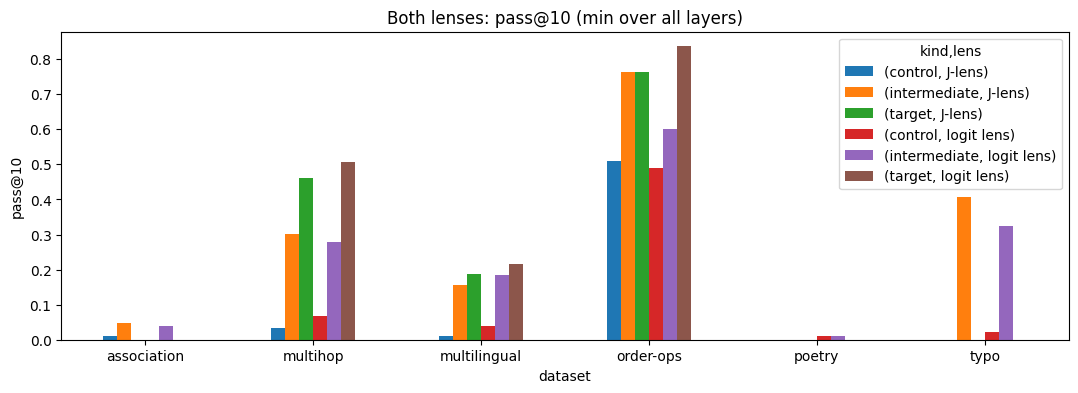

"J-lens − logit lens, inner pass@k",intermediate,control,target
dataset,,,
association,0.010,0.010,NaN
multihop,0.000,-0.047,-0.118
multilingual,-0.028,-0.030,-0.037
order-ops,0.127,-0.020,-0.145
poetry,-0.010,-0.010,NaN
typo,0.083,-0.021,NaN


In [19]:
at_k = scores[scores.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
at_k.plot.bar(figsize=(13, 4), rot=0, title=f"Both lenses: pass@{K} (min over all layers)")
plt.ylabel(f"pass@{K}")
plt.show()

inner_at_k = inner[inner.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
output_at_k = output[output.k == K].pivot(index="dataset", columns=["kind", "lens"], values="score")
inner_delta = pd.DataFrame({
    kind: inner_at_k[(kind, "J-lens")] - inner_at_k[(kind, "logit lens")]
    for kind in ("intermediate", "control", "target")
})
display(inner_delta.rename_axis(columns="J-lens − logit lens, inner pass@k").round(3))

## 4. At what depth do the words surface?

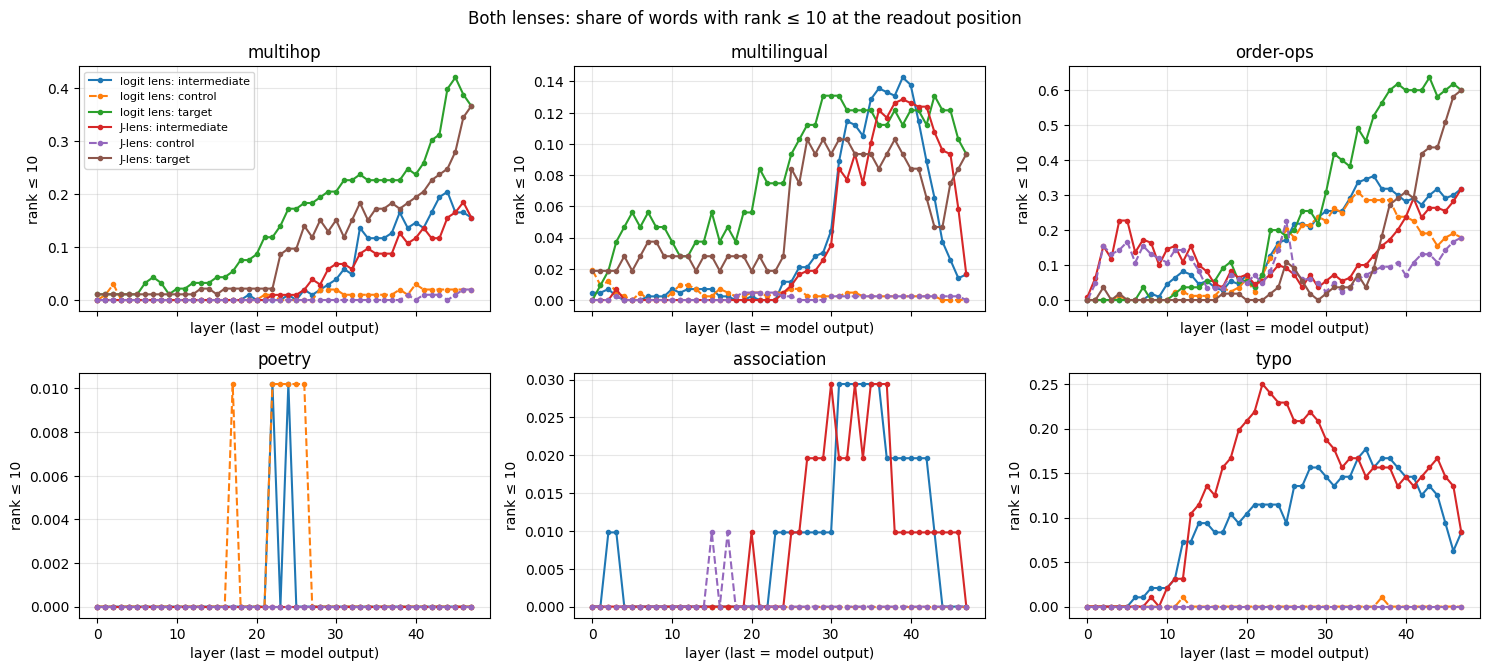

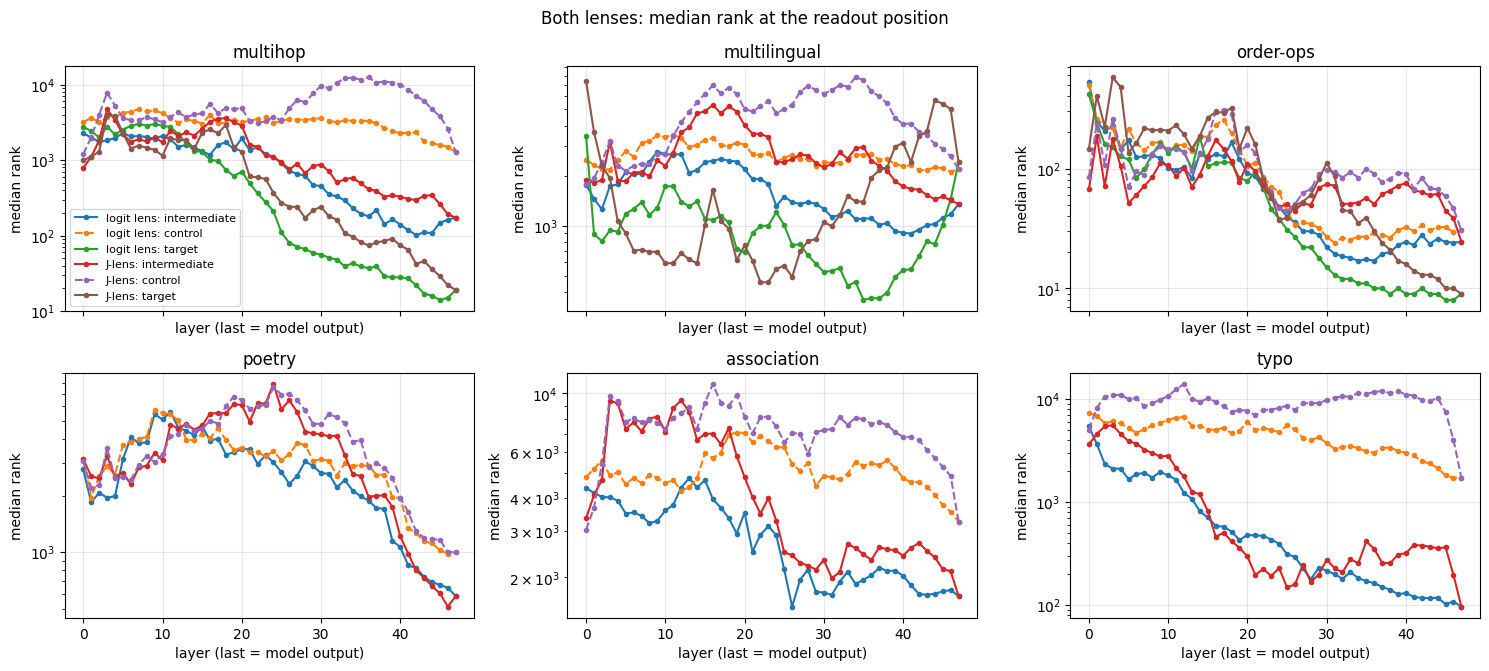

In [20]:
def word_curves(stat):
    return {
        f"{name}: {kind}": stat(words[(words.lens == name) & (words.kind == kind)])
        for name in LENS_NAMES
        for kind in ("intermediate", "control", "target")
    }


plot_layer_curves(
    word_curves(lambda frame: layer_hit_rate(frame, K)),
    title=f"Both lenses: share of words with rank ≤ {K} at the readout position",
    ylabel=f"rank ≤ {K}",
)
plot_layer_curves(
    word_curves(layer_median_rank),
    title="Both lenses: median rank at the readout position",
    ylabel="median rank",
    logy=True,
)

Where the best rank of each intermediate is reached (only words that are hits, rank ≤ K):

In [21]:
(
    inter[inter.best_rank <= K]
    .groupby(["dataset", "lens"]).best_layer.value_counts().unstack(fill_value=0)
    .reindex(columns=range(gpt.n_layers), fill_value=0)
)

best_layer               0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16  17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43  44  45  46  47
dataset      lens                                                                                                                                                                                                      
association  J-lens       0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   1   0   0   1   0   0   1   0   0   0   0   0   1   0   0   0   0   0   0   0   0
             logit lens   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   1   1   0   0   0   1   0   0   0   0   0   0   0   0   0
multihop     J-lens       0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   1   0   1   2   0   0   0   0   2   4   0   2   1   0   1   2   3   8
             logit lens   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   1   0   0   0   0   1   0   3   0   1   1   0   1   0   1   4   5   3   1   3
multilingual J-lens       0   0   0   3   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   3   1   1   1   2   6   2   6   0   4   5   4   3   9   6   1   3   3   0   2   1   1
             logit lens   2   0   3   0   0   0   0   0   0   1   1   1   0   2   0   1   0   0   0   0   1   0   0   0   0   0   2   1   5   1   0   8   3   7   1   7   8  12   5   3   3   0   1   0   0   0   0   0
order-ops    J-lens       0   0   1   0   1   7   1   6   2   0   1   4   0   3   0   3   0   0   0   2   0   0   0   2   1   3   1   0   0   1   0   0   1   0   1   1   1   2   0   2   2   5   2   6   2   1   5  14
             logit lens   0   0   0   0   0   0   0   0   0   0   0   2   0   1   0   1   1   0   0   0   2   0   1   2   0   0   1   1   3   3   2   1   2   5   1   5   2   5   4   2   2   2   2   1   1   6   1   4
poetry       logit lens   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
typo         J-lens       0   0   0   0   0   0   0   0   0   0   0   1   2   0   3   0   1   0   2   0   3   3   4   1   1   3   0   1   2   0   1   0   0   0   0   0   1   0   2   0   0   1   1   2   1   0   3   0
             logit lens   0   0   0   0   0   0   0   0   0   0   0   0   2   2   1   2   0   1   1   1   1   2   0   0   0   0   1   2   0   1   0   2   1   1   1   1   1   1   1   0   0   0   0   3   0   0   0   2

## 5. How both lenses behave in general

Over all prompt positions (not only the readout one):

* **agreement** — the layer's top-1 equals the model's top-1: how deep the final prediction is formed;
* **copy rate** — the layer's top-1 is the input token at that position: the residual stream still "is" the token embedding
  (GPT-2 ties `wte` and `lm_head`, so an untouched embedding decodes to itself);
* **KL(model ‖ layer)** — how far the layer's distribution is from the output one.

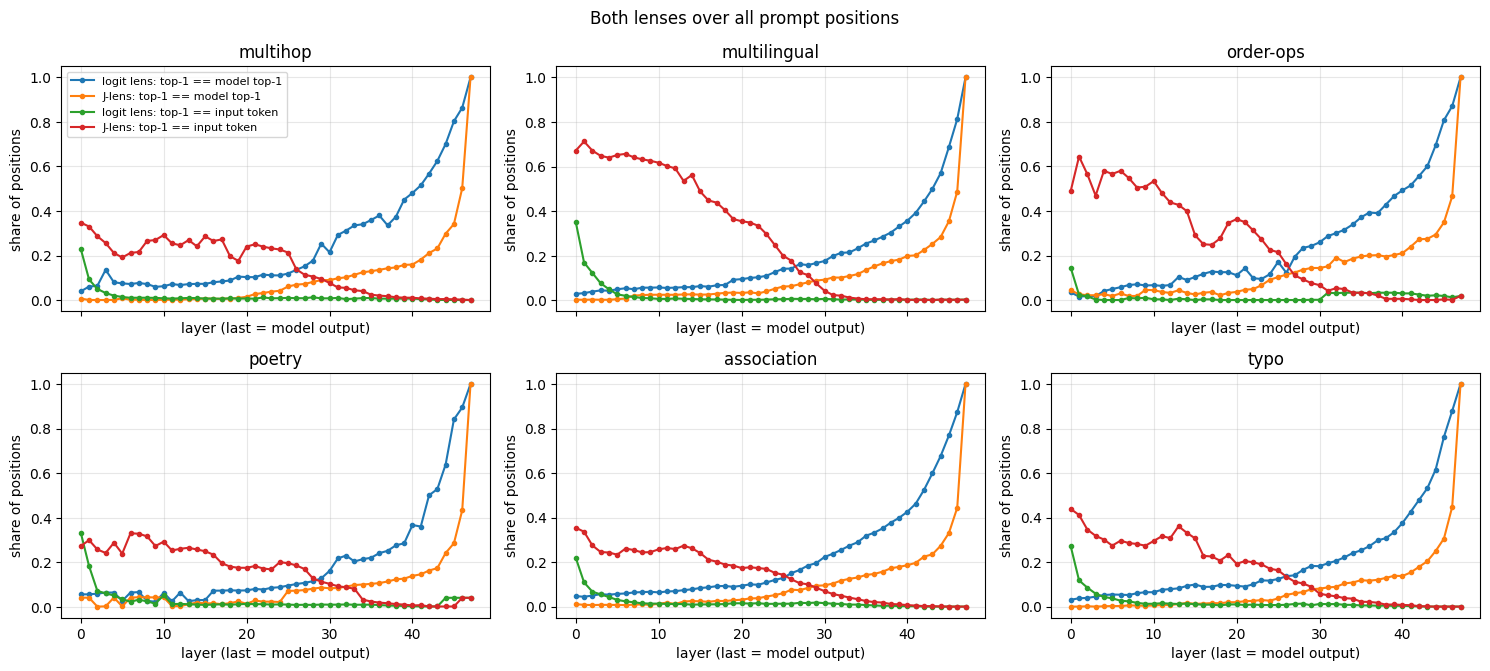

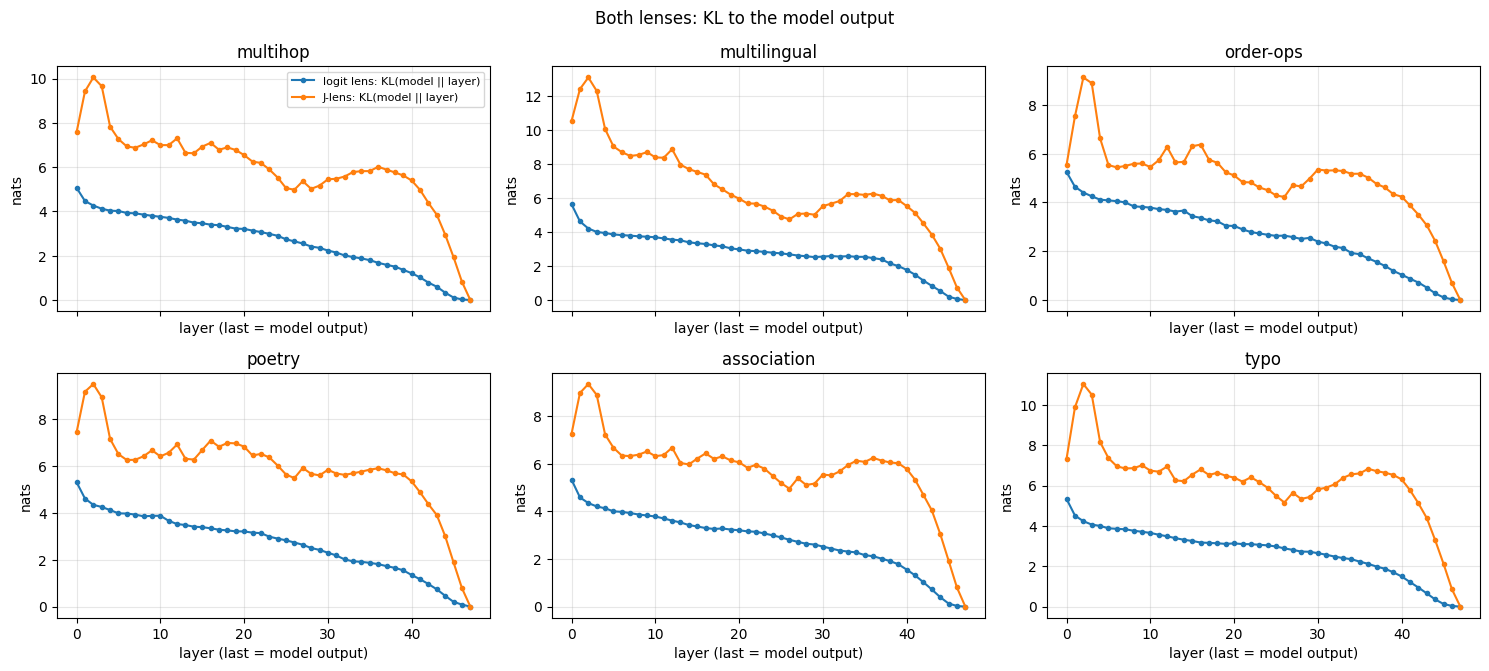

In [22]:
behaviour = {
    name: {column: layer_mean(items[items.lens == name], column)
           for column in ("agreement", "copy_rate", "kl_to_final")}
    for name in LENS_NAMES
}
plot_layer_curves(
    {f"{name}: top-1 == model top-1": behaviour[name]["agreement"] for name in LENS_NAMES}
    | {f"{name}: top-1 == input token": behaviour[name]["copy_rate"] for name in LENS_NAMES},
    title="Both lenses over all prompt positions",
    ylabel="share of positions",
)
plot_layer_curves(
    {f"{name}: KL(model || layer)": behaviour[name]["kl_to_final"] for name in LENS_NAMES},
    title="Both lenses: KL to the model output",
    ylabel="nats",
)

In [23]:
behaviour_rows = []
for name in LENS_NAMES:
    agreement, copy_rate, kl = (behaviour[name][c] for c in ("agreement", "copy_rate", "kl_to_final"))
    for dataset in agreement.index:
        behaviour_rows.append({
            "dataset": dataset,
            "lens": name,
            "agreement ≥ 50% from": first_layer(agreement.loc[dataset], 0.5),
            "KL ≤ 1 nat from": first_layer(kl.loc[dataset], 1.0, above=False),
            "copy rate at L0": copy_rate.loc[dataset, 0],
            f"copy rate at L{LAST - 1}": copy_rate.loc[dataset, LAST - 1],
        })
pd.DataFrame(behaviour_rows).set_index(["dataset", "lens"]).unstack("lens").round(3)

agreement ≥ 50% from            KL ≤ 1 nat from            copy rate at L0            copy rate at L46           
lens                       J-lens logit lens          J-lens logit lens          J-lens logit lens           J-lens logit lens
dataset                                                                                                                       
association                    47         42              46         43           0.354      0.219            0.000      0.000
multihop                       46         41              46         42           0.348      0.230            0.002      0.000
multilingual                   47         44              46         43           0.672      0.351            0.002      0.002
order-ops                      47         41              46         41           0.491      0.144            0.001      0.012
poetry                         47         42              46         42           0.272      0.333            0.040      0.040
typo                           47         43              46         42           0.439      0.270            0.000      0.000

## 6. What drives a hit

### 6a. The word is already in the prompt

Early layers of the logit lens decode the input token itself, so a word that is literally in the prompt
(e.g. a number in order-ops) can be a "hit" without any computation.

In [24]:
hits = inter.assign(hit=inter.best_rank <= K, inner_hit=inter.inner_best <= K)
hits.groupby(["dataset", "in_prompt", "lens"]).hit.agg(["mean", "size"]).unstack(["in_prompt", "lens"]).round(3)

mean                                size                             
in_prompt     False             True              False             True            
lens         J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                             
association   0.040      0.030  0.500      0.500  100.0      100.0    2.0        2.0
multihop      0.265      0.245  1.000      1.000  102.0      102.0    1.0        1.0
multilingual  0.157      0.184  0.133      0.200  413.0      413.0   15.0       15.0
order-ops     0.768      0.857  0.759      0.333   56.0       56.0   54.0       54.0
poetry        0.000      0.010    NaN        NaN   98.0       98.0    NaN        NaN
typo          0.411      0.326  0.000      0.000   95.0       95.0    1.0        1.0

### 6b. Single-token words vs words that only have a first-token fallback

In [25]:
hits.groupby(["dataset", "single_token", "lens"]).hit.agg(["mean", "size"]).unstack(["single_token", "lens"]).round(3)

mean                                size                             
single_token  False             True              False             True            
lens         J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                             
association   0.222      0.333  0.032      0.011    9.0        9.0   93.0       93.0
multihop        NaN        NaN  0.272      0.252    NaN        NaN  103.0      103.0
multilingual  0.033      0.100  0.166      0.191   30.0       30.0  398.0      398.0
order-ops       NaN        NaN  0.764      0.600    NaN        NaN  110.0      110.0
poetry          NaN        NaN  0.000      0.010    NaN        NaN   98.0       98.0
typo            NaN        NaN  0.406      0.323    NaN        NaN   96.0       96.0

### 6c. Role of the intermediate

multilingual: `[language, relation, source word, answer in English]`; order-ops: `[intermediate number, operation]`.

In [26]:
roles = hits[hits.dataset.isin(list(ROLE_NAMES))].copy()
roles["role_name"] = [ROLE_NAMES[d][r] for d, r in zip(roles.dataset, roles.role)]
roles.groupby(["dataset", "role_name", "lens"]).agg(
    hit_rate=("hit", "mean"), median_best_rank=("best_rank", "median"), n=("hit", "size"),
    inner_hit_rate=("inner_hit", "mean"), median_inner_rank=("inner_best", "median"),
).unstack("lens").round(3)

hit_rate            median_best_rank                 n            inner_hit_rate            median_inner_rank           
lens                               J-lens logit lens           J-lens logit lens J-lens logit lens         J-lens logit lens            J-lens logit lens
dataset      role_name                                                                                                                                   
multilingual answer (English)       0.065      0.084            512.0      265.0    107        107          0.065      0.084             512.0      265.0
             language               0.439      0.542             14.0        7.0    107        107          0.439      0.542              14.0        7.0
             relation               0.028      0.028            859.0      727.0    107        107          0.028      0.028             859.0      727.0
             source word            0.093      0.084            328.0      209.0    107        107          0.093      0.084             361.0      210.0
order-ops    intermediate number    0.764      0.909              7.0        4.0     55         55          0.727      0.891               7.0        4.0
             operation              0.764      0.291              6.0       19.0     55         55          0.691      0.273               6.0       19.0

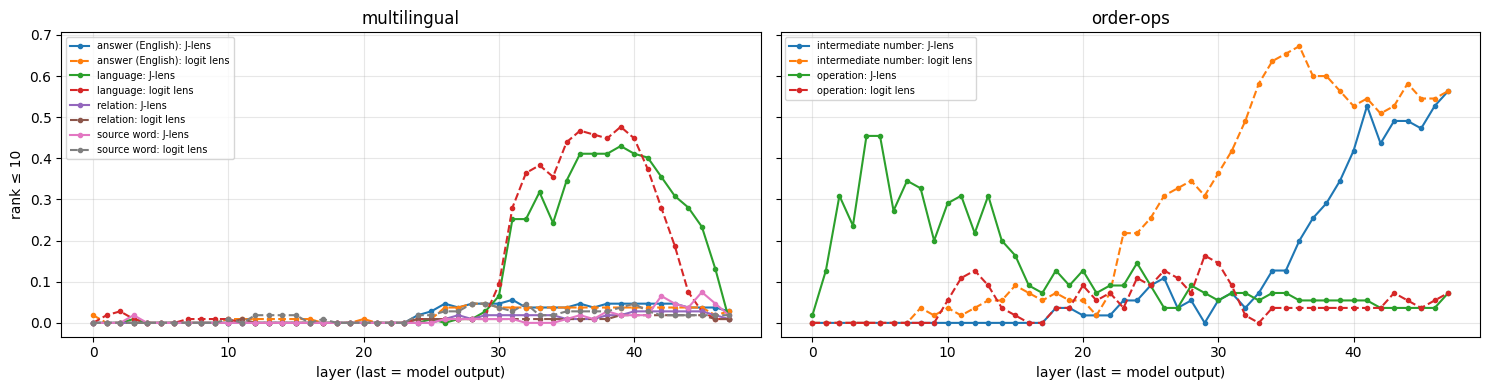

In [27]:
fig, axes = plt.subplots(1, len(ROLE_NAMES), figsize=(15, 4), sharey=True, squeeze=False)
for ax, dataset in zip(axes.flat, ROLE_NAMES):
    group = roles[roles.dataset == dataset]
    for (role, name), role_group in group.groupby(["role_name", "lens"]):
        ax.plot(
            (np.stack(role_group.ranks) <= K).mean(0), marker="o", ms=3,
            label=f"{role}: {name}", linestyle="--" if name == "logit lens" else "-",
        )
    ax.set_title(dataset)
    ax.set_xlabel("layer (last = model output)")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=7)
axes.flat[0].set_ylabel(f"rank ≤ {K}")
plt.tight_layout()
plt.show()

### 6d. Does the intermediate show up more often when the model gets the answer right?

In [28]:
correctness = hits.merge(
    with_target[["dataset", "item", "model_correct"]], on=["dataset", "item"], validate="many_to_one"
)
correctness.groupby(["dataset", "model_correct", "lens"]).hit.agg(["mean", "size"]).unstack(["model_correct", "lens"]).round(3)

mean                                size                             
model_correct  False             True              False             True            
lens          J-lens logit lens J-lens logit lens J-lens logit lens J-lens logit lens
dataset                                                                              
multihop       0.271      0.240  0.286      0.429     96         96      7          7
multilingual   0.160      0.189  0.062      0.062    412        412     16         16
order-ops      0.769      0.602  0.500      0.500    108        108      2          2

## 7. Items: successes and failures

In [29]:
columns = ["dataset", "item", "lens", "word", "best_rank", "best_layer", "inner_best", "inner_best_layer", "in_prompt"]
inter.sort_values("best_rank").groupby(["dataset", "lens"]).head(3)[columns]

,dataset,item,lens,word,best_rank,best_layer,inner_best,inner_best_layer,in_prompt
4140,typo,typo-water,J-lens,water,1,44,1,44,False
2038,multilingual,fr-time-after-night,logit lens,French,1,33,1,33,False
2047,multilingual,fr-time-after-night,J-lens,French,1,35,1,35,False
2056,multilingual,de-time-after-night,logit lens,German,1,31,1,31,False
4008,typo,typo-family,J-lens,family,1,22,1,22,False
4026,typo,typo-power,logit lens,power,1,33,1,33,False
4028,typo,typo-power,J-lens,power,1,38,1,38,False
2351,multilingual,de-time-old-new,J-lens,German,1,37,1,37,False
1995,multilingual,fr-color-night,J-lens,French,1,39,1,39,False
1986,multilingual,fr-color-night,logit lens,French,1,35,1,35,False


In [30]:
inter.sort_values("best_rank", ascending=False).groupby(["dataset", "lens"]).head(3)[columns]

,dataset,item,lens,word,best_rank,best_layer,inner_best,inner_best_layer,in_prompt
843,multilingual,turkish-opposite-fast,logit lens,opposite,23568,13,23568,13,False
1359,multilingual,german-phase-water,logit lens,freeze,22323,1,22323,1,False
852,multilingual,turkish-opposite-fast,J-lens,opposite,21472,0,21472,0,False
1422,multilingual,serbian-opposite-day,J-lens,opposite,20900,0,20900,0,False
1341,multilingual,spanish-phase-water,logit lens,freeze,20465,6,20465,6,False
1494,multilingual,irish-opposite-big,J-lens,opposite,17105,7,17105,7,False
3394,association,grief,logit lens,grief,9159,37,9159,37,False
3446,association,beatles,logit lens,Beatles,7132,44,7132,44,False
3148,poetry,couplet-smoke-spoke,J-lens,spoke,6580,5,6580,5,False
3448,association,beatles,J-lens,Beatles,5782,41,5782,41,False


What the lens reads at the readout position, layer by layer (first items of each dataset):

In [31]:
readout = items.groupby(["dataset", "lens"]).head(2).set_index(["dataset", "item", "lens"]).readout_top1.apply(pd.Series)
readout.columns.name = "layer"
readout.sort_index()[shown_layers(gpt.n_layers, LAYER_STRIDE)]

layer                                               0         4         8          12           16          20           24          28          32          36                40           44     47
dataset      item                 lens                                                                                                                                                               
association  grief                J-lens            \n         —      \n\n       \n\n         \n\n        \n\n          She         She         She         She               She          She     \n
                                  logit lens         I         I        He         He           He         She          She         She         She         She               She          She     \n
             pregnant             J-lens                       …      \n\n       \n\n         \n\n         She      herself         She         She         She               She          She     \n
                                  logit lens         I         I        He         He           He         She          She         She         She         She               She          She     \n
multihop     amazon-language      J-lens            \n         —      \n\n       \n\n            ―           —          NOT       slang   languages   languages        Portuguese   Portuguese    not
                                  logit lens       not       not    likely     likely       likely      called   profoundly   identical   bilingual      spoken            called          not    not
             carnival-ocean       J-lens                       '      \n\n       \n\n         Tall           ​      largest     largest     largest     busiest           richest        ocean   most
                                  logit lens      rest      most      same       very         same     largest      largest     largest     largest     largest           largest         most   most
multilingual french-season-summer J-lens             '        -'        -'         -'           -'          -'           -'    MpServer          ét          ét                ét           ét      é
                                  logit lens         €        bl         n       same         same     highest            €          de          ét          ét                ét           ét      é
             spanish-opposite-big J-lens             "         "         "          "           bc          ="      shorter       grand       grand       grand             grand        grand  grand
                                  logit lens         "         K       ign        ign         just        real         tall       grand       grand       grand             grand        grand  grand
order-ops    parens-add-mult      J-lens                       =         =          =            =           =        Total       Total       Total       Total                36           24     24
                                  logit lens  ========  ========  ========   ========         conc           £        Total       Total       Total           8                12           24     24
             parens-sub-mult      J-lens                       =         =   ========            =           =            9           9           9           9                16           16     16
                                  logit lens         0  ========       ===   ========            9           9            9           9           9           9                16           16     16
poetry       couplet-breath-death J-lens             —         —        \n                                                                                                  while        Until    The
                                  logit lens        \n       bra       Ted         ca         Lent                                              And         And               And          The    The
             couplet-stone-bone   J-lens

The most common readout top-1 tokens per layer over all items — generic tokens mean the lens shows no item-specific content there:

In [32]:
top1_tables = {}
for name in LENS_NAMES:
    top1_by_layer = pd.DataFrame(items[items.lens == name].readout_top1.tolist())
    top1_tables[name] = pd.DataFrame({
        "distinct top-1 / items": top1_by_layer.nunique() / len(top1_by_layer),
        "most common": {
            layer: ", ".join(f"{token!r}×{count}" for token, count in column.value_counts().head(5).items())
            for layer, column in top1_by_layer.items()
        },
    }).rename_axis("layer")
pd.concat(top1_tables, axis=1, names=["lens", "metric"])

lens               logit lens                                                                    J-lens                                                   
metric distinct top-1 / items                                        most common distinct top-1 / items                                        most common
layer                                                                                                                                                     
0                    0.237750      '\n'×98, ' "'×93, ' I'×76, ' not'×21, ' 0'×21               0.190563  '\xa0'×166, '"'×79, ' \xad'×62, '\n'×49, ' and...
1                    0.225045  ' I'×97, '"'×78, ' "'×75, ' not'×54, '========...               0.214156  ' —'×137, ' "'×106, ' \xad'×77, ' ='×47, ' and...
2                    0.219601  ' I'×143, ' "'×70, ' not'×58, '"'×47, '=======...               0.210526        ' —'×217, ' "'×96, ' ='×43, ' '×28, " '"×17
3                    0.239564  ' I'×158, ' not'×59, ' "'×47, '========'×45, '...               0.232305     ' —'×106, ' "'×96, "?'"×62, '\xa0'×45, ' …'×32
4                    0.259528  ' I'×100, ' not'×59, '========'×44, '"'×35, '\...               0.219601      ' —'×157, ' "'×96, ' ='×44, ' …'×24, ' --'×18
5                    0.248639  ' I'×88, ' not'×49, '========'×47, ' bra'×42, ...               0.208711     " '"×104, ' "'×93, '\n\n'×79, ' …'×51, ' ='×47
6                    0.292196  ' Maiden'×63, '========'×47, ' I'×41, ' The'×3...               0.212341   '\n\n'×127, ' "'×91, '\n'×83, ' ='×40, ' ...'×31
7                    0.286751  ' It'×49, '========'×46, ' sm'×39, '\n'×39, ' ...               0.214156     '\n\n'×155, '\n'×96, ' "'×87, ' ='×40, ' …'×18
8                    0.279492  ' sm'×56, '========'×44, ' likely'×39, ' It'×3...               0.217786     '\n\n'×169, '\n'×96, ' "'×90, ' ='×26, ' >'×21
9                    0.303085  'WA'×41, '========'×30, ' likely'×29, ' It'×29...               0.232305  '\n\n'×165, ' "'×88, ' Caps'×54, ' Mine'×37, '...
10                   0.313975  ' It'×46, '========'×28, ' te'×26, ' likely'×2...               0.241379  '\n\n'×159, '\xa0'×98, ' "'×92, ' ='×38, ' equ...
11                   0.313975  ' lull'×57, ' It'×42, '========'×32, ' He'×26,...               0.245009  '\n\n'×158, '\xa0'×96, ' "'×88, ' ='×38, ' equ...
12                   0.321234  'ca'×54, ' It'×52, '========'×34, ' lull'×30, ...               0.255898  '\n\n'×152, '\xa0'×97, ' "'×83, ' ='×31, '====...
13                   0.326679  ' It'×55, ' lull'×46, '========'×27, '\xa0'×26...               0.274047  '\n\n'×101, '\xa0'×98, ' ".'×34, ' "'×34, ' ='×30
14                   0.341198  '\xa0'×41, ' It'×40, ' He'×29, ' supposed'×19,...               0.283122   '\xa0'×98, '\n\n'×96, ' "'×59, ' ='×34, ' ".'×19
15                   0.339383  ' te'×85, ' It'×40, '========'×23, ' He'×23, '...               0.286751  '\n\n'×100, '\xa0'×98, ' ."'×31, ' �'×27, ' ='×26
16                   0.373866  ' te'×46, ' He'×28, ' It'×26, '========'×20, '...               0.299456   '\xa0'×98, '\n\n'×91, ' ."'×18, ' ='×17, ' >'×17
17                   0.399274   'Mah'×44, '\xa0'×30, '\n'×26, ' He'×21, ' It'×18               0.292196    '\n\n'×99, '\xa0'×98, '/"'×29, ' >'×22, ' �'×14
18                   0.424682  'Solution'×34, '\xa0'×20, '\n'×20, ' conc'×18,...               0.321234  '\xa0'×94, '\n\n'×87, '/"'×29, ' Puzzle'×28, '...
19                   0.421053  '\xa0'×84, '\n'×12, ' probably'×11, '�'×11, ' ...               0.324864   '\xa0'×99, '\n\n'×63, ' ='×44, ':"'×27, ' ".'×19
20                   0.415608    '\xa0'×78, '\n'×17, ' He'×15, '�'×12, 'real'×11               0.332123  '\xa0'×99, '\n\n'×71, ' ='×45, ':"'×43, ' .......
21                   0.399274  '\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\...               0.362976   '\xa0'×98, '\n\n'×57, ':"'×53, ' ='×45, ' ".'×14
22                   0.402904  '\xa0'×43, '\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0\x...               0.388385     '\xa0'×97, ':"'×4

### 7a. Paired inner-layer ranks: which lens improves each intermediate?

One row per intermediate occurrence, aligned by dataset, item, word, and role. A positive
`log10 gain` means J-lens lowers the best inner-layer rank; ties are counted explicitly.

In [33]:
head_to_head = inter.pivot(
    index=["dataset", "item", "word", "role"], columns="lens", values="inner_best"
)
head_to_head["winner"] = np.select(
    [head_to_head["J-lens"] < head_to_head["logit lens"],
     head_to_head["J-lens"] > head_to_head["logit lens"]],
    ["J-lens", "logit lens"], default="tie",
)
head_to_head["log10 gain"] = np.log10(head_to_head["logit lens"]) - np.log10(head_to_head["J-lens"])
paired_summary = head_to_head.groupby("dataset").winner.value_counts().unstack(fill_value=0)
paired_summary = paired_summary.reindex(columns=["J-lens", "logit lens", "tie"], fill_value=0)
paired_summary["median log10 gain"] = head_to_head.groupby("dataset")["log10 gain"].median()
display(paired_summary.round(3))
display(head_to_head.sort_values("log10 gain", ascending=False).head(15))
display(head_to_head.sort_values("log10 gain").head(15))

winner,J-lens,logit lens,tie,median log10 gain
dataset,,,,
association,66,36,0,0.181
multihop,48,46,9,0.000
multilingual,150,250,28,-0.121
order-ops,54,41,15,0.000
poetry,53,45,0,0.056
typo,47,38,11,0.000


lens                                               J-lens  logit lens  winner  log10 gain
dataset      item                  word      role                                        
typo         typo-which            which     0         13        1612  J-lens    2.093422
             typo-another          another   0          1         110  J-lens    2.041393
             typo-different        different 0          1          40  J-lens    1.602060
             typo-because          because   0          3         117  J-lens    1.591065
             typo-within           within    0          3         106  J-lens    1.548185
             typo-until            until     0          2          44  J-lens    1.342423
multilingual bulgarian-color-grass color     1         98        1987  J-lens    1.306972
             de-size-big-small     size      1        137        2717  J-lens    1.297369
order-ops    mod-add               mod       1          1          17  J-lens    1.230449
poetry       couplet-lock-key      key       0         26         440  J-lens    1.228479
order-ops    floordiv-mult         division  1          5          69  J-lens    1.139879
multilingual russian-number-four   number    1        106        1460  J-lens    1.139047
order-ops    floordiv-add          division  1          4          53  J-lens    1.122216
multilingual hungarian-color-sea   color     1        168        2194  J-lens    1.115927
order-ops    parens-add-div        division  1          5          65  J-lens    1.113943

lens                                                  J-lens  logit lens      winner  log10 gain
dataset      item                     word      role                                            
multilingual fr-half-six              six       2        220           1  logit lens   -2.342423
             frn-number-after-one     two       3        165           3  logit lens   -1.740363
             de-size-big-small        small     3        538          13  logit lens   -1.616839
             irish-opposite-big       small     3        475          17  logit lens   -1.446245
             portuguese-season-spring season    1       5021         196  logit lens   -1.408534
poetry       couplet-fight-light      light     0        696          29  logit lens   -1.380211
order-ops    sub-mult-right           12        0         24           1  logit lens   -1.380211
multilingual pt-time-after-night      time      1        972          45  logit lens   -1.334454
             de-place-near-far        far       3        233          11  logit lens   -1.325963
             french-season-summer     summer    2        567          27  logit lens   -1.322219
             bulgarian-color-grass    Bulgarian 0        101           5  logit lens   -1.305351
             spanish-number-three     three     2        301          15  logit lens   -1.302475
             fr-half-six              three     3        193          10  logit lens   -1.285557
poetry       couplet-flight-night     night     0        460          25  logit lens   -1.264818
multilingual es-time-after-day        time      1        310          17  logit lens   -1.260913

## 8. Adaptations of reference Figures 52, 55, and 56

These reproduce **plot forms, not the reference experiment**: this notebook uses the loaded GPT-2 model/J-lens and local evaluation sets, not the reference model or necessarily its sample subsets. The original exact sample subsets and symmetric-KL normalization are unknown. There is **no tuned lens** and no Sonnet workspace shading. See `docs/reference_plots.md` and `docs/lens_metrics.md`.

### 8a. Figure 52: intermediate hit rate versus k (no new inference)
Only annotated **single-token intermediates** are included; first-token fallbacks are excluded. For each k, take each word's best rank over **all blocks, including the shared final model output**, average word hits within an item, then average items. Items with no retained words are omitted, not counted as failures. The table discloses excluded word occurrences and items **per lens** (paired annotations are repeated). Tokenization/accepted spelling variants are this evaluator's, not a guaranteed match to the reference. Cached ranks also inherit `evaluate_paired()`'s `prompt.rstrip()` before tokenization: trailing whitespace is removed, potentially changing tokenization and the final-token readout position relative to the original prompt. This adaptation is not a whitespace-exact reference reproduction; established evaluation semantics are unchanged.

Panel legends report trapezoidal AUC versus **log(k)** normalized by log(100/1), on k = 1, 2, 5, 10, 20, 50, 100. AUC and hit rates range from 0 to 1. Black = J-lens; red = logit lens.

,dataset,lens,n_words_total,n_words_used,n_words_excluded,n_items_total,n_items_used,n_items_excluded
0,association,J-lens,102,93,9,102,93,9
1,association,logit lens,102,93,9,102,93,9
2,multihop,J-lens,103,103,0,93,93,0
3,multihop,logit lens,103,103,0,93,93,0
4,multilingual,J-lens,428,398,30,107,107,0
5,multilingual,logit lens,428,398,30,107,107,0
6,order-ops,J-lens,110,110,0,55,55,0
7,order-ops,logit lens,110,110,0,55,55,0
8,poetry,J-lens,98,98,0,98,98,0
9,poetry,logit lens,98,98,0,98,98,0


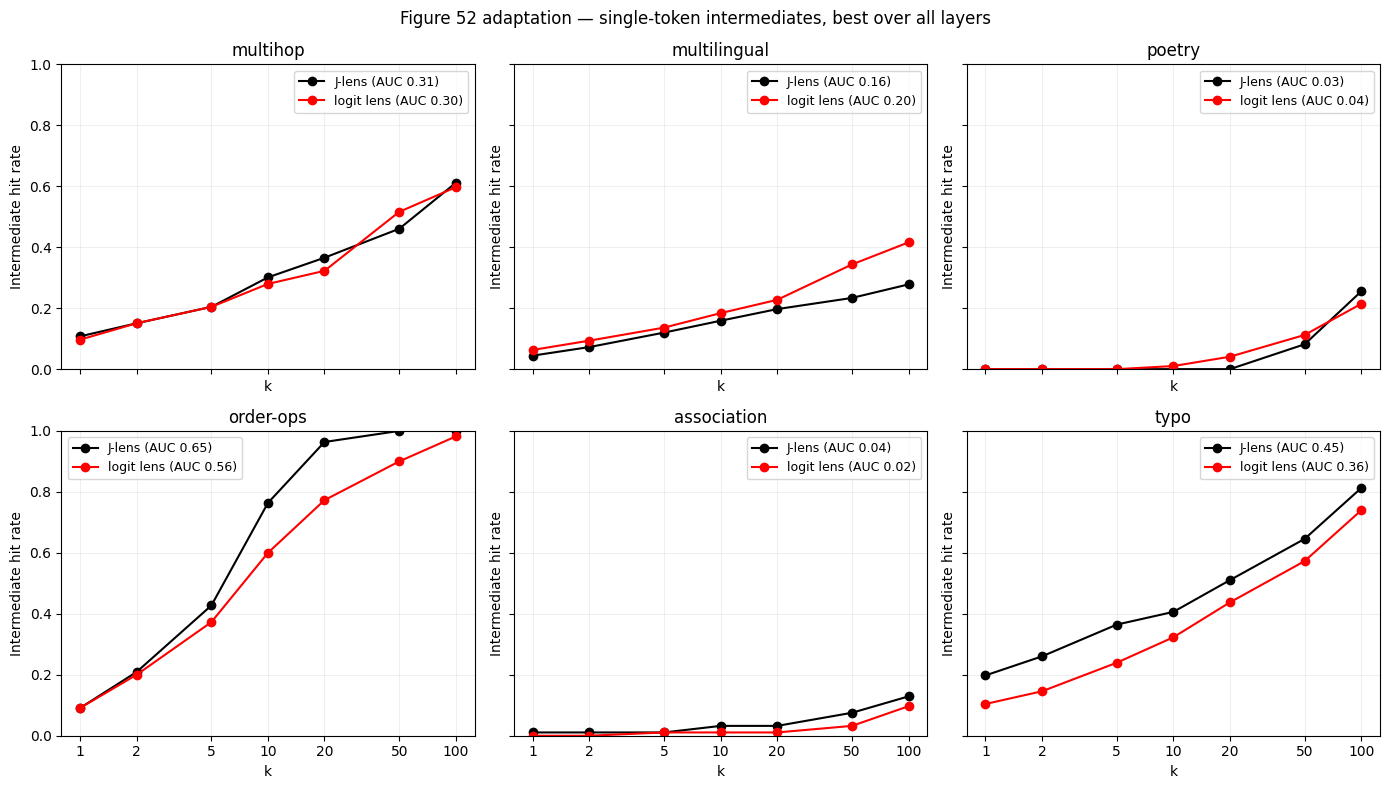

In [34]:
from jlens.reference_plots import (
    intermediate_rank_sweep, plot_intermediate_sweep,
    plot_distribution_summary, plot_lens_comparison,
)

reference52 = intermediate_rank_sweep(words)
display(reference52.counts)
fig52, axes52 = plot_intermediate_sweep(reference52)
plt.show()

### 8b. Figures 55/56: explicitly supplied held-out text (opt-in extra evaluation)
**No refit is needed.** These distribution metrics cannot be recovered from `words`/`items`; they require new forwards with the already loaded model/lens. Default is **disabled**. Supply your own independent texts below (not the fitting corpus or task prompts) and name their source. No downloads or automatic corpus substitution occur. A small held-out sample is a diagnostic, not a reproduction of pretraining-distribution results. Keep a record of sample selection and fitting provenance.

All actual model blocks are evaluated. Depth = 100 * block_index / (n_blocks - 1): first block output 0, shared final output 100; no embedding row. Means weight every non-special input position equally, including each text's last position, after per-text truncation. Longer texts contribute more tokens. Natural-log KL and entropy are in **nats**.

* **55:** KL(model || lens), lens entropy, and top-1 agreement with model **in percent**. J-lens blue, logit lens purple.
* **56:** one purple J/logit comparison at each **same layer**: vocabulary-vector cosine, **0.5 * (KL(J || logit) + KL(logit || J))**, and top-1 agreement **as a fraction**. This half-sum convention is explicit; the original normalization is unknown. Cross-layer pairs are never averaged.
* Cosine compares corresponding rows of W_U and W_U @ J, averaged equally over nonzero vocabulary-vector pairs. It is **linear-head-only geometry**, excluding bias, final normalization, and softcap, not an exact global geometry for the nonlinear decoder. Unsupported geometry is labeled unavailable, not zero. See the status/counts table. The cosine axis uses the reference's **0 to 1** range for nonnegative/unavailable results; if any displayed value is negative, it adaptively extends to **-1 to 1** and the plot title discloses this extension. Real negative cosines are never silently clipped.

Start with a few short held-out texts: all-layer readouts can be expensive on GPT-2 XL. Position chunk size bounds vocabulary-distribution memory, not activation/Jacobian memory. Reduce it or sequence length if needed. Evaluation and plotting are separate cells so plots can be regenerated without forwards.

In [35]:
# Opt in by editing these two values. Keep this sample independent of lens fitting.
HELD_OUT_TEXTS = None  # e.g. a list[str] of your held-out passages
HELD_OUT_SOURCE = ""  # corpus/version, split, sample selection; no private text needed
# Local-file example (one independently held-out passage per nonempty line):
# HELD_OUT_TEXTS = [s for s in Path('/path/to/heldout.txt').read_text().splitlines() if s.strip()]
# HELD_OUT_SOURCE = 'my-corpus v1, held-out split, first 8 passages (disjoint from fitting)'
HELD_OUT_MAX_SEQ_LEN = 128
HELD_OUT_POSITION_CHUNK_SIZE = 4
GEOMETRY_VOCAB_CHUNK_SIZE = 1024

In [36]:
# Clear cached results first so a disabled/failed rerun cannot plot stale metrics.
held_out_metrics = held_out_geometry = held_out_run = None
if HELD_OUT_TEXTS is None:
    print('Figures 55/56 skipped: supply independent HELD_OUT_TEXTS and HELD_OUT_SOURCE above. No downloads or extra evaluation run.')
else:
    if not isinstance(HELD_OUT_TEXTS, (list, tuple)) or not HELD_OUT_TEXTS:
        raise ValueError('Supply a nonempty list/tuple of independently held-out strings.')
    if not all(isinstance(text, str) and text.strip() for text in HELD_OUT_TEXTS):
        raise ValueError('Every held-out passage must be a nonempty string.')
    if not HELD_OUT_SOURCE.strip():
        raise ValueError('Describe the independent sample in HELD_OUT_SOURCE first.')
    from jlens.metrics import evaluate_distributions, lens_vector_geometry

    held_out_run = {
        'model': globals().get('MODEL_ID', type(gpt).__name__),
        'source': HELD_OUT_SOURCE, 'n_texts_supplied': len(HELD_OUT_TEXTS),
        'max_seq_len': HELD_OUT_MAX_SEQ_LEN,
        'position_chunk_size': HELD_OUT_POSITION_CHUNK_SIZE,
        'layers': 'all blocks, shared final output', 'weighting': 'token',
        'float32_matmul_precision': torch.get_float32_matmul_precision(),
    }
    display(held_out_run)
    held_out_metrics = evaluate_distributions(
        gpt, fitted_lens, HELD_OUT_TEXTS, layers=None,
        max_seq_len=HELD_OUT_MAX_SEQ_LEN,
        position_chunk_size=HELD_OUT_POSITION_CHUNK_SIZE, pairwise=True,
    )
    held_out_geometry = lens_vector_geometry(
        gpt, fitted_lens, layers=None, vocab_chunk_size=GEOMETRY_VOCAB_CHUNK_SIZE,
    )
    display(held_out_metrics.layers)
    display(held_out_geometry)

Figures 55/56 skipped: supply independent HELD_OUT_TEXTS and HELD_OUT_SOURCE above. No downloads or extra evaluation run.


In [37]:
fig55 = axes55 = fig56 = axes56 = None
if held_out_metrics is None or held_out_geometry is None:
    print('No held-out figures to plot. Configure the sample and run the evaluation cell first.')
else:
    print('Held-out sample:', held_out_run['source'])
    fig55, axes55 = plot_distribution_summary(held_out_metrics.layers, n_layers=gpt.n_layers)
    plt.show()
    fig56, axes56 = plot_lens_comparison(
        held_out_metrics.pairs, held_out_geometry, n_layers=gpt.n_layers,
    )
    plt.show()

No held-out figures to plot. Configure the sample and run the evaluation cell first.


## 9. Conclusions

The cell below turns the numbers above into statements, so they stay correct after a re-run
(other seed, other `K`, other model size).

In [38]:
def pct(x):
    return "n/a" if x is None or pd.isna(x) else f"{100 * x:.0f}%"


def layer(x):
    return "never" if x is None else f"L{x}"


def hit_rates(frame, column):
    """Hit rate (best rank <= K) split by a boolean column: {value: (rate, n)}."""
    hit = (frame.best_rank <= K).groupby(frame[column])
    return {value: (rate, n) for value, rate, n in zip(hit.mean().index, hit.mean(), hit.size())}

In [39]:
lines = ["Model accuracy (top-1 == target): " + ", ".join(f"{d} {pct(a)}" for d, a in accuracy.items()) + "."]
for name in LENS_NAMES:
    lines.append(f"--- {name} ---")
    lens_at_k = at_k.xs(name, axis=1, level="lens")
    inner_lens_at_k = inner_at_k.xs(name, axis=1, level="lens")
    output_lens_at_k = output_at_k.xs(name, axis=1, level="lens")
    lens_inter = inter[inter.lens == name]
    inter_curve = layer_hit_rate(lens_inter, K)
    target_curve = layer_hit_rate(target[target.lens == name], K)
    agreement, copy_rate, kl = (behaviour[name][c] for c in ("agreement", "copy_rate", "kl_to_final"))
    lens_roles = roles[roles.lens == name]
    lens_correctness = correctness[correctness.lens == name]
    for dataset in lens_at_k.index:
        i, c = lens_at_k.loc[dataset, "intermediate"], lens_at_k.loc[dataset].get("control")
        verdict = "clearly above" if i >= c + 0.1 else "slightly above" if i > c else "NOT above"
        peak = inter_curve.loc[dataset].iloc[:-1]
        lines.append(
            f"{dataset}: intermediates pass@{K} {pct(i)} vs control {pct(c)} — {verdict} chance; "
            f"inner layers alone {pct(inner_lens_at_k.loc[dataset, 'intermediate'])}, model output alone "
            f"{pct(output_lens_at_k.loc[dataset, 'intermediate'])}; best inner layer L{peak.idxmax()} "
            f"({pct(peak.max())} of words at rank ≤ {K})."
        )

    for dataset in target_curve.index:
        curve = target_curve.loc[dataset]
        if curve.iloc[-1] == 0:
            lines.append(f"{dataset}: the target is never in the output top-{K}.")
        else:
            lines.append(
                f"{dataset}: the target is in the output top-{K} for {pct(curve.iloc[-1])} of items "
                f"and reaches half of that by {layer(first_layer(curve, curve.iloc[-1] / 2))}."
            )

    for dataset in agreement.index:
        lines.append(
            f"{dataset}: lens top-1 == model top-1 on ≥50% of positions from {layer(first_layer(agreement.loc[dataset], 0.5))}, "
            f"KL ≤ 1 nat from {layer(first_layer(kl.loc[dataset], 1.0, above=False))}; copy rate "
            f"{pct(copy_rate.loc[dataset, 0])} at L0 → {pct(copy_rate.loc[dataset, LAST - 1])} at L{LAST - 1}."
        )

    for column, yes, no in [
        ("in_prompt", "already in the prompt", "absent from it"),
        ("single_token", "single-token", "first-token fallback"),
    ]:
        rates = hit_rates(lens_inter, column)
        (r_yes, n_yes), (r_no, n_no) = rates.get(True, (None, 0)), rates.get(False, (None, 0))
        lines.append(f"Intermediates {yes}: hit rate {pct(r_yes)} (n={n_yes}) vs {pct(r_no)} (n={n_no}) {no}.")

    for dataset, group in lens_roles.groupby("dataset"):
        by_role = group.groupby("role_name").hit.mean().sort_values(ascending=False)
        lines.append(f"{dataset} by role: " + ", ".join(f"{name} {pct(rate)}" for name, rate in by_role.items()) + ".")

    by_correct = lens_correctness.groupby("model_correct").hit.mean()
    lines.append(
        f"Intermediate hit rate when the model is right: {pct(by_correct.get(True))}, when wrong: {pct(by_correct.get(False))}."
    )


for dataset in inner_at_k.index:
    row = inner_at_k.loc[dataset]
    j, l = row[("intermediate", "J-lens")], row[("intermediate", "logit lens")]
    jc, lc = row[("control", "J-lens")], row[("control", "logit lens")]
    lines.append(
        f"{dataset}: inner-layer pass@{K}, J-lens {pct(j)} vs logit lens {pct(l)} "
        f"(Δ {100 * (j - l):+.1f} pp); margins over control "
        f"{100 * (j - jc):+.1f} pp vs {100 * (l - lc):+.1f} pp."
    )
for dataset, row in paired_summary.iterrows():
    lines.append(
        f"{dataset}: J-lens ranks intermediates higher in {row.get('J-lens', 0):.0f} cases, "
        f"logit lens in {row.get('logit lens', 0):.0f}, ties {row.get('tie', 0):.0f}; "
        f"median log10 rank gain {row['median log10 gain']:+.2f}."
    )
for line in lines:
    print("•", line)

• Model accuracy (top-1 == target): multihop 8%, multilingual 4%, order-ops 2%.
• --- logit lens ---
• association: intermediates pass@10 4% vs control 0% — slightly above chance; inner layers alone 4%, model output alone 0%; best inner layer L31 (3% of words at rank ≤ 10).
• multihop: intermediates pass@10 28% vs control 7% — clearly above chance; inner layers alone 28%, model output alone 17%; best inner layer L44 (20% of words at rank ≤ 10).
• multilingual: intermediates pass@10 18% vs control 4% — clearly above chance; inner layers alone 18%, model output alone 2%; best inner layer L39 (14% of words at rank ≤ 10).
• order-ops: intermediates pass@10 60% vs control 49% — clearly above chance; inner layers alone 58%, model output alone 32%; best inner layer L36 (35% of words at rank ≤ 10).
• poetry: intermediates pass@10 1% vs control 1% — NOT above chance; inner layers alone 1%, model output alone 0%; best inner layer L22 (1% of words at rank ≤ 10).
• typo: intermediates pass@10 32% 

### How to read these numbers

* **Intermediates vs control.** Compare each lens with its control baseline and compare the
  margins between lenses. A larger raw hit rate alone does not establish better intermediate readout.
* **Inner layers vs model output.** Both lenses use the exact same model output. All-layer
  metrics preserve the original analysis; inner-layer pass@k and the paired ranks isolate
  differences in the lens. An inner-layer hit is suggestive, not proof of a reasoning step.
* **Copy rate.** High early-layer copy rates can explain hits for words already in the prompt.
  Compare both lenses' copy curves and the in-prompt split (§6a).
* **Agreement / KL.** Earlier agreement and lower KL describe fidelity to the model output;
  they do not by themselves show that intermediates are exposed better.
* **Model correctness.** Accuracy is measured once per item. The right/wrong split keeps
  both lens measurements attached to that same model answer.
* **Tokenization.** Multi-token words fall back to their first token, which can be generic.
  The single-token split (§6b) retains this diagnostic. Controls share the dataset topic.
* **Fit corpus.** A J-lens depends on its fitting corpus and selected model. Use an independent
  corpus, keep the checkpoint with its model, and vary the mix to test sensitivity.